# Co-Authorship Network and Research Community Detection
Alex Bradshaw, 1861973

## About
The goal of this analysis is to map co-author relationships across venues.

## Tasks
1. Map co-author networks within and across venues/conferences
2. Use graph clustering to identify research communities/groups
3. Analyze collaboration patterns (do certain author groups dominate certain venues?)

## Motivations
- Identify tight-knit research communities and key bridge figures who connect disparate groups
- Understand collaboration culture: do certain venues/subfields favor collaboration while others are individual-focused?
- Discover hidden research hierarchies: who are the central figures in each community? How do newcomers break in?
- Reveal informal networks: papers often come from established research groups; understanding these networks provides insights into how research is actually conducted

## Challenges
- Author disambiguation: Same name can refer to different authors; misspellings and name variations make exact matching difficult
- Scale variation: Some authors publish 100+ papers, others 1-2; co-authorship graph has highly skewed degree distribution
- Temporal changes: Research communities evolve; some authors exit, new collaborators emerge; static snapshots miss this dynamic
- Defining "communities": Different clustering algorithms (Louvain, K-clique, etc.) can yield very different community structures

In [ ]:
"""Import Dependencies"""
import json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import gc
import community as community_louvain
import seaborn as sns


In [ ]:
"""Globals/Constants"""
DATA_PATH = './dblp_ref/'

TOP_N = 25  # number of top venues to visualize in the venue co-citation graph
TOP_N_AUTHORS = 25 # number of top authors to visualize in the co-authorship graph

MIN_AUTHOR_PAPERS     = 5   # minimum papers to qualify as a core author
MAX_AUTHORS_PER_PAPER = 10  # caps the author-pair inner loop
MAX_REFS_PER_PAPER    = 30  # cap reference list per paper

MIN_EDGE_WEIGHT = 3   # minimum cross-citation weight to keep an edge

TOP_COMMUNITIES = 10 # number of top communities to analyze
TOP_AUTHORS_PER_COMMUNITY = 5 # number of top authors to list per community (based on degree centrality) 

TOP_VENUES_T3 = 20  # how many venues to include

In [4]:
"""Helper/Utility Functions"""
def read_json_lines(file_path):
    """Reads the JSON file at the given path and yeilds each line (record)."""
    with open(file_path) as json_file:
        for line in json_file:
            yield json.loads(line)

def load_data_from_file(file_path) -> pd.DataFrame:
    """Loads the data from the given file path and returns a concatenated DataFrame."""
    frames = []
    for file_index in range(4):
        file_name = f'{ file_path }dblp-ref-{ file_index }.json'
        print(f"Loading file { file_name } ({ file_index + 1 }/4)...")
        frames.append(pd.DataFrame(read_json_lines(file_name)))

    print("Concatenating Data Frames...")
    return pd.concat(frames)


In [ ]:
"""Load Data"""
# papers = load_data_from_file(DATA_PATH)
papers = pd.read_pickle('cleaned_dataset.pkl')

/tmp/ipykernel_40149/2299806441.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', TOP_N)


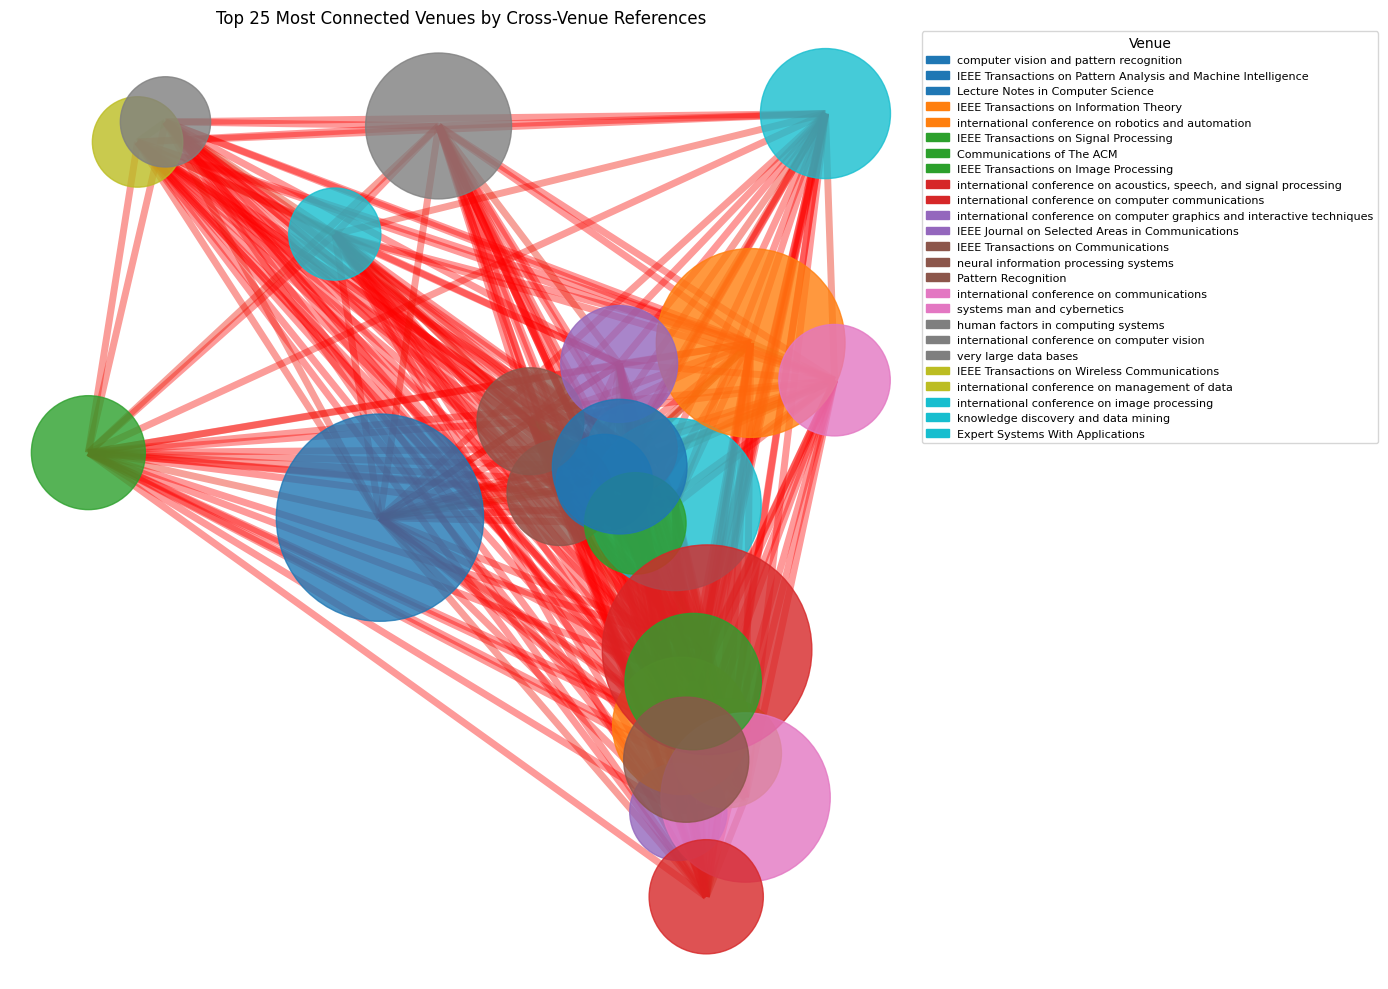

In [ ]:
"""Task 1: Map Co-Author Networks Within and Across Venues/Conferences
    
    Task 1.a: Build a graph where nodes are venues and edges represent cross-venue citations. Analyze the graph to identify clusters of closely related venues and visualize the relationships.
"""

sample_set = papers[
    papers['venue'].notna()
    & (papers['venue'].astype(str).str.strip() != '')
    & (papers['n_citation'] > 0)
    & papers['references'].notna()
]


# Build venue-level graph based on cross-venue references
venue_published = {}  
venue_referenced = {}

for paper in sample_set.itertuples():
    venue = paper.venue
    if venue not in venue_published:
        venue_published[venue] = []
        venue_referenced[venue] = []
    venue_published[venue].append(paper.id)
    if isinstance(paper.references, list):
        venue_referenced[venue].extend(paper.references)

# paper_id → venue index
paper_to_venue = {pid: venue for venue, pids in venue_published.items() for pid in pids}

venue_graph = nx.Graph()
for venue, pids in venue_published.items():
    venue_graph.add_node(venue, size=len(pids))

# Count cross-venue references
edge_weights = {}
for src_venue, refs in venue_referenced.items():
    for ref_id in refs:
        tgt_venue = paper_to_venue.get(ref_id)
        if tgt_venue and tgt_venue != src_venue:
            key = (min(src_venue, tgt_venue), max(src_venue, tgt_venue))
            edge_weights[key] = edge_weights.get(key, 0) + 1

for (v1, v2), weight in edge_weights.items():
    venue_graph.add_edge(v1, v2, weight=weight)


# Filter to top N venues by weighted degree
scores = {node: venue_graph.degree(node, weight='weight') for node in venue_graph.nodes()}
top_venues = sorted(scores, key=scores.get, reverse=True)[:TOP_N] # type: ignore
subgraph = venue_graph.subgraph(top_venues)

cmap = plt.get_cmap('tab10', TOP_N)
venue_colors = {venue: cmap(i) for i, venue in enumerate(top_venues)}

nodes = list(subgraph.nodes())
max_weight = max((d['weight'] for _, _, d in subgraph.edges(data=True)), default=1)
no_edge_dist = 10.0 / max_weight

layout_graph = nx.complete_graph(len(nodes))
layout_graph = nx.relabel_nodes(layout_graph, dict(enumerate(nodes)))
for u, v in layout_graph.edges():
    if subgraph.has_edge(u, v):
        layout_graph[u][v]['weight'] = 1.0 / subgraph[u][v]['weight']
    else:
        layout_graph[u][v]['weight'] = no_edge_dist

pos = nx.kamada_kawai_layout(layout_graph, weight='weight')

plt.figure(figsize=(14, 10))
node_sizes = [subgraph.nodes[n]['size'] for n in subgraph.nodes()]
edge_widths = [subgraph[u][v]['weight'] / 10 for u, v in subgraph.edges()]
node_colors = [venue_colors[n] for n in subgraph.nodes()]

weights = np.array([subgraph[u][v]['weight'] for u, v in subgraph.edges()], dtype=float)
norm_weights = (weights - weights.min()) / (weights.max() - weights.min()) if weights.max() > weights.min() else np.zeros_like(weights)
edge_colors = [(1 - w, w, 0, 1) for w in norm_weights]

nx.draw_networkx_edges(subgraph, pos, width=5, alpha=0.4, edge_color=edge_colors)
nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, alpha=0.8, node_color=node_colors)

from matplotlib.patches import Patch
legend_handles = [Patch(color=venue_colors[v], label=v) for v in top_venues]
plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=8, title='Venue')

plt.title(f'Top {TOP_N} Most Connected Venues by Cross-Venue References')
plt.axis('off')
plt.tight_layout()
plt.show()


Pass 1/3: counting author publication counts…
  259,563 core authors (≥ 5 papers)
Pass 2/3: building paper → core-author index…
  1,914,498 papers indexed
Pass 3/3: counting cross-author citation edges…
  51,979,466 unique author-pair edges
Author graph: 259,563 nodes, 51,979,466 edges


/tmp/ipykernel_40149/888723373.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  author_cmap = plt.cm.get_cmap('tab20', TOP_N_AUTHORS)


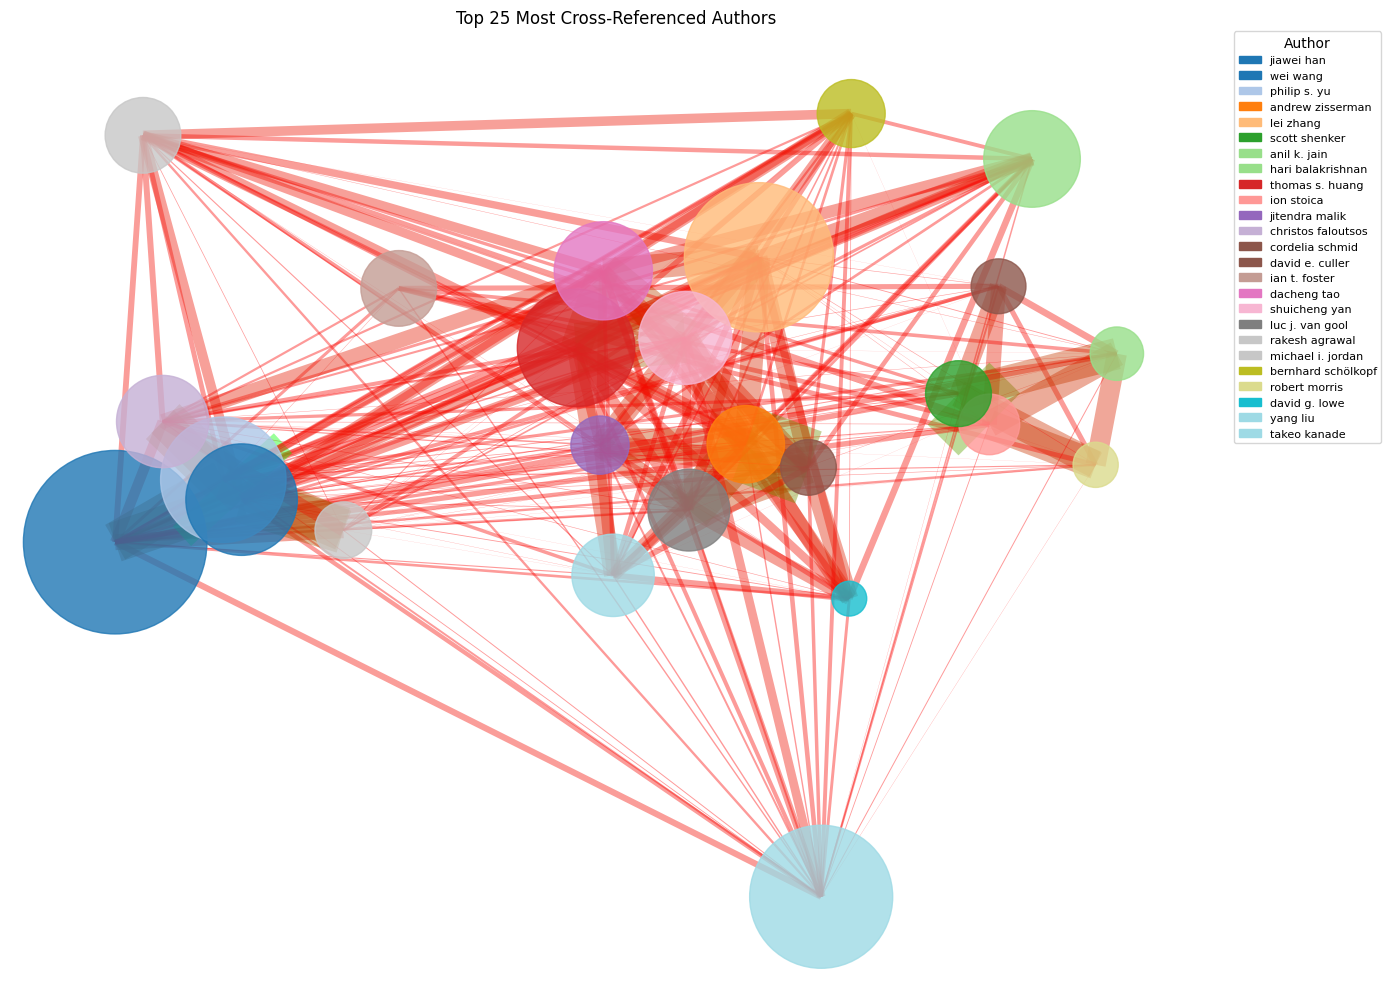

In [ ]:
"""Task 1.b: Build a graph where nodes are authors and edges represent cross-author citations (i.e., author A cites author B). Analyze the graph to identify influential authors and research communities, and visualize the relationships."""

# Pass 1: count publications per author; encode as integers to reduce memory
print("Pass 1/3: counting author publication counts…")
raw_pub_count = defaultdict(int)
for paper in sample_set.itertuples():
    if not isinstance(paper.authors, list):
        continue
    for author in paper.authors[:MAX_AUTHORS_PER_PAPER]:
        raw_pub_count[author] += 1

core_authors_list = [a for a, c in raw_pub_count.items() if c >= MIN_AUTHOR_PAPERS]
author_to_idx     = {a: i for i, a in enumerate(core_authors_list)}
core_pub_counts   = np.array([raw_pub_count[a] for a in core_authors_list], dtype=np.int32)
del raw_pub_count
gc.collect()
print(f"  {len(author_to_idx):,} core authors (≥ {MIN_AUTHOR_PAPERS} papers)")

# Pass 2: build paper → core-author index
print("Pass 2/3: building paper → core-author index…")
paper_to_authors = {}
for paper in sample_set.itertuples():
    if not isinstance(paper.authors, list):
        continue
    core = [author_to_idx[a] for a in paper.authors[:MAX_AUTHORS_PER_PAPER]
            if a in author_to_idx]
    if core:
        paper_to_authors[paper.id] = core

print(f"  {len(paper_to_authors):,} papers indexed")
gc.collect()

# Pass 3: count cross-author citation edges
print("Pass 3/3: counting cross-author citation edges…")
author_edge_weights = defaultdict(int)
for paper in sample_set.itertuples():
    if not isinstance(paper.authors, list) or not isinstance(paper.references, list):
        continue
    citing = [author_to_idx[a] for a in paper.authors[:MAX_AUTHORS_PER_PAPER]
              if a in author_to_idx]
    if not citing:
        continue
    for ref_id in paper.references[:MAX_REFS_PER_PAPER]:
        cited = paper_to_authors.get(ref_id)
        if not cited:
            continue
        for src in citing:
            for tgt in cited:
                if src != tgt:
                    key = (src, tgt) if src < tgt else (tgt, src)
                    author_edge_weights[key] += 1

print(f"  {len(author_edge_weights):,} unique author-pair edges")
del paper_to_authors
gc.collect()

# Build author graph
author_graph = nx.Graph()
author_graph.add_nodes_from(
    (core_authors_list[i], {'size': int(core_pub_counts[i])})
    for i in range(len(core_authors_list))
)
author_graph.add_edges_from(
    (core_authors_list[i], core_authors_list[j], {'weight': w})
    for (i, j), w in author_edge_weights.items()
)
del author_edge_weights, core_pub_counts
gc.collect()
print(f"Author graph: {author_graph.number_of_nodes():,} nodes, {author_graph.number_of_edges():,} edges")


# Filter to top N authors by weighted degree
author_scores = {node: author_graph.degree(node, weight='weight') for node in author_graph.nodes()}
top_authors = sorted(author_scores, key=author_scores.get, reverse=True)[:TOP_N_AUTHORS] # type: ignore
author_subgraph = author_graph.subgraph(top_authors)

author_cmap = plt.get_cmap('tab20', TOP_N_AUTHORS)
author_colors = {author: author_cmap(i) for i, author in enumerate(top_authors)}

author_max_weight = max((d['weight'] for _, _, d in author_subgraph.edges(data=True)), default=1)
author_no_edge_dist = 10.0 / author_max_weight

author_layout_graph = nx.complete_graph(len(top_authors))
author_layout_graph = nx.relabel_nodes(author_layout_graph, dict(enumerate(top_authors)))
for u, v in author_layout_graph.edges():
    if author_subgraph.has_edge(u, v):
        author_layout_graph[u][v]['weight'] = 1.0 / author_subgraph[u][v]['weight']
    else:
        author_layout_graph[u][v]['weight'] = author_no_edge_dist

author_pos = nx.kamada_kawai_layout(author_layout_graph, weight='weight')
plt.figure(figsize=(14, 10))
author_node_sizes = [author_subgraph.nodes[n]['size'] * 10 for n in author_subgraph.nodes()]
author_edge_raw = np.array([author_subgraph[u][v]['weight'] for u, v in author_subgraph.edges()], dtype=float)
author_edge_widths = [author_subgraph[u][v]['weight'] / 10 for u, v in author_subgraph.edges()]
author_norm_weights = (author_edge_raw - author_edge_raw.min()) / (author_edge_raw.max() - author_edge_raw.min()) if author_edge_raw.max() > author_edge_raw.min() else np.zeros_like(author_edge_raw)
author_edge_colors = [(1 - w, w, 0, 1) for w in author_norm_weights]
author_node_colors = [author_colors[n] for n in author_subgraph.nodes()]

nx.draw_networkx_edges(author_subgraph, author_pos, width=author_edge_widths, alpha=0.4, edge_color=author_edge_colors)
nx.draw_networkx_nodes(author_subgraph, author_pos, node_size=author_node_sizes, alpha=0.8, node_color=author_node_colors)

from matplotlib.patches import Patch
author_legend_handles = [Patch(color=author_colors[a], label=a) for a in top_authors]
plt.legend(handles=author_legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=8, title='Author')

plt.title(f'Top {TOP_N_AUTHORS} Most Cross-Referenced Authors')
plt.axis('off')
plt.tight_layout()
plt.show()


## Task 1 output

```shell
Pass 1/3: counting author publication counts…
  259,563 core authors (≥ 5 papers)
Pass 2/3: building paper → core-author index…
  1,914,498 papers indexed
Pass 3/3: counting cross-author citation edges…
  51,979,466 unique author-pair edges
Author graph: 259,563 nodes, 51,979,466 edges
```

Building core graph (direct edge filter, no full copy)…
Core graph: 252,650 nodes, 9,574,722 edges
Running Louvain…

Total communities detected: 334
Showing top 10 communities by member count:

  Community  1 — 31756 authors | hub: andrew zisserman
  Community  2 — 26753 authors | hub: scott shenker
  Community  3 — 24306 authors | hub: ian t. foster
  Community  4 — 22678 authors | hub: jiawei han
  Community  5 — 20553 authors | hub: sebastian thrun
  Community  6 — 18563 authors | hub: francisco herrera
  Community  7 — 16192 authors | hub: thomas a. henzinger
  Community  8 — 16065 authors | hub: gregory d. abowd
  Community  9 — 15660 authors | hub: jeffrey g. andrews
  Community 10 — 13209 authors | hub: robert endre tarjan


/tmp/ipykernel_40149/1049738045.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  comm_cmap = plt.cm.get_cmap('tab10', TOP_COMMUNITIES)


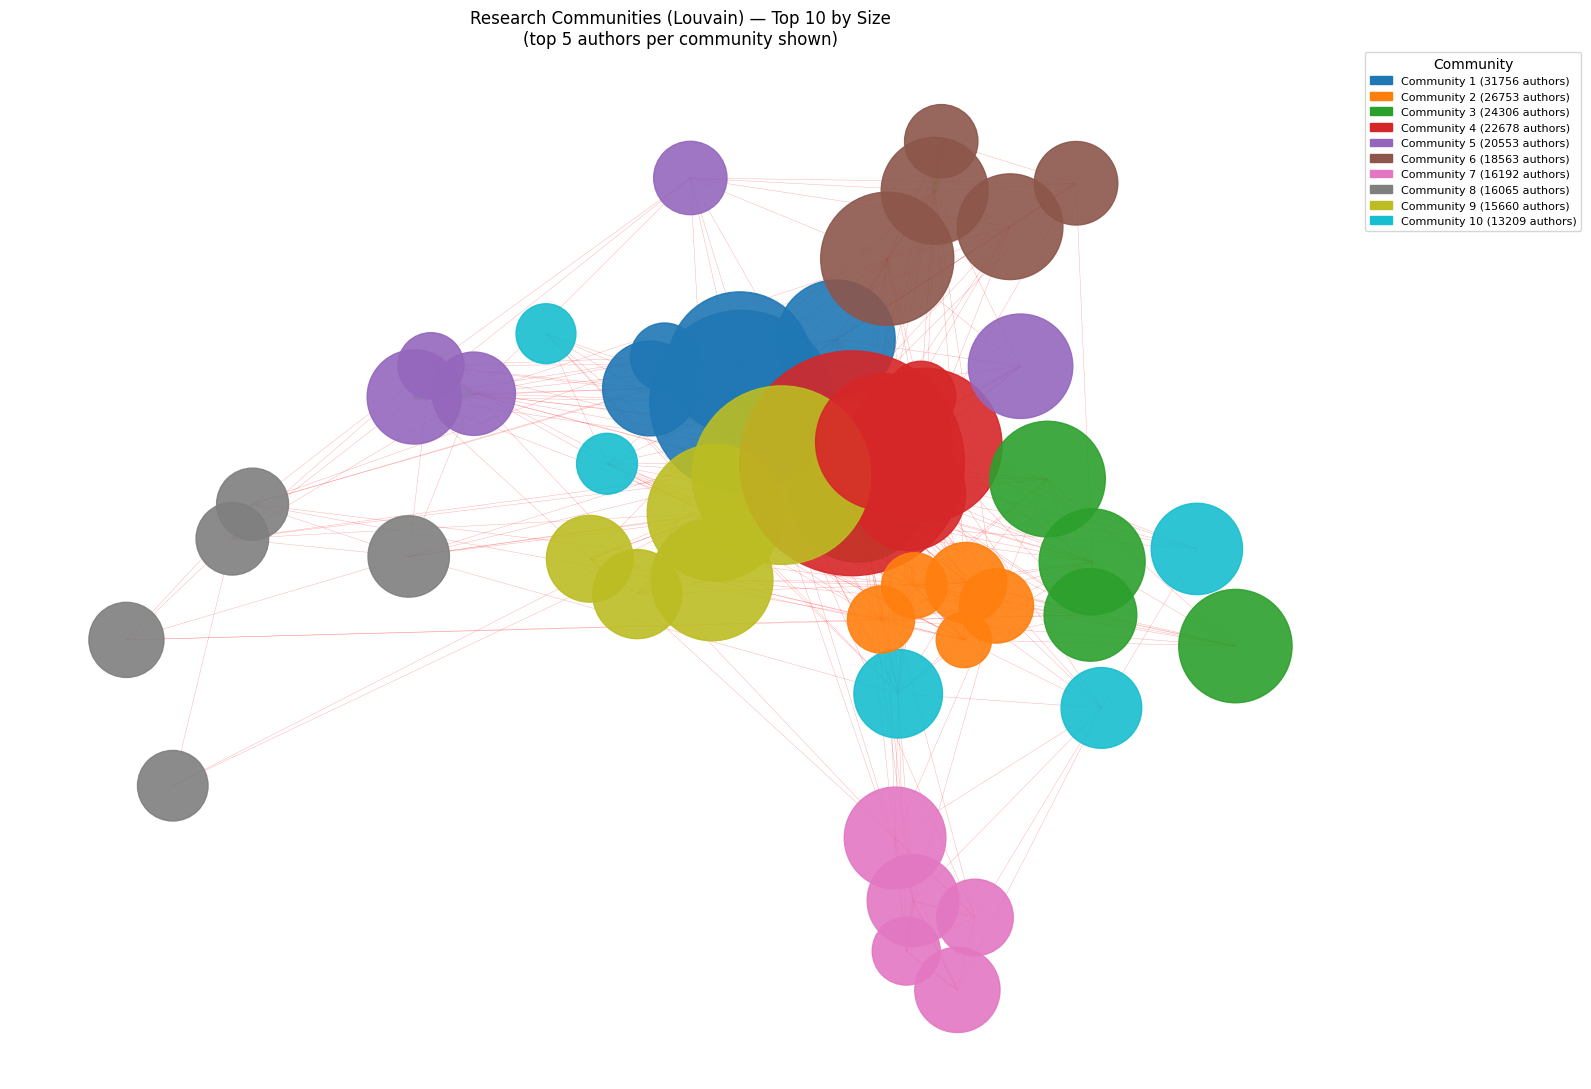

In [ ]:
"""Task 2: Use graph clustering to identify research communities/groups"""

# Build core_graph by streaming qualifying edges — avoids copying the full author_graph
print("Building core graph (direct edge filter, no full copy)…")
core_graph = nx.Graph()

core_graph.add_nodes_from(author_graph.nodes(data=True))

# Keep only edges meeting the weight threshold
core_graph.add_edges_from(
    (u, v, d) for u, v, d in author_graph.edges(data=True)
    if d.get('weight', 0) >= MIN_EDGE_WEIGHT
)

# Drop isolated nodes
core_graph.remove_nodes_from(list(nx.isolates(core_graph)))

del author_graph
gc.collect()

print(f"Core graph: {core_graph.number_of_nodes():,} nodes, {core_graph.number_of_edges():,} edges")

# Run Louvain community detection
print("Running Louvain…")
partition = community_louvain.best_partition(core_graph, weight='weight', random_state=42)

# community id → member list
communities = {}
for author, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(author)

top_comm_ids = sorted(communities, key=lambda c: len(communities[c]), reverse=True)[:TOP_COMMUNITIES]

print(f"\nTotal communities detected: {len(communities)}")
print(f"Showing top {TOP_COMMUNITIES} communities by member count:\n")
for rank, cid in enumerate(top_comm_ids, 1):
    members = communities[cid]
    hub = max(members, key=lambda a: core_graph.degree(a, weight='weight'))
    print(f"  Community {rank:>2} — {len(members):>4} authors | hub: {hub}")


# Visualise top K authors per community
vis_authors = []
for cid in top_comm_ids:
    members = communities[cid]
    top_k = sorted(members, key=lambda a: core_graph.degree(a, weight='weight'), reverse=True)[:TOP_AUTHORS_PER_COMMUNITY]
    vis_authors.extend(top_k)

comm_subgraph = core_graph.subgraph(vis_authors)

comm_cmap = plt.get_cmap('tab10', TOP_COMMUNITIES)
comm_color_map = {cid: comm_cmap(i) for i, cid in enumerate(top_comm_ids)}
comm_node_colors = [comm_color_map[partition[n]] for n in comm_subgraph.nodes()]

comm_pos = nx.spring_layout(
    comm_subgraph,
    weight='weight',
    seed=42,
    k=3 / (len(vis_authors) ** 0.5),
    iterations=100,
)

comm_node_sizes = [core_graph.nodes[n]['size'] * 15 for n in comm_subgraph.nodes()]
comm_edge_raw = np.array([comm_subgraph[u][v]['weight'] for u, v in comm_subgraph.edges()], dtype=float)
comm_edge_widths = (np.clip(comm_edge_raw / comm_edge_raw.max() * 5, 0.3, 5).tolist()
                    if comm_edge_raw.size else [])
comm_norm_e = ((comm_edge_raw - comm_edge_raw.min()) / (comm_edge_raw.max() - comm_edge_raw.min())
               if comm_edge_raw.size and comm_edge_raw.max() > comm_edge_raw.min()
               else np.zeros_like(comm_edge_raw))
comm_edge_colors = [(1 - w, w, 0, 1) for w in comm_norm_e]

plt.figure(figsize=(16, 11))
nx.draw_networkx_edges(comm_subgraph, comm_pos, width=comm_edge_widths,
                       alpha=0.35, edge_color=comm_edge_colors)
nx.draw_networkx_nodes(comm_subgraph, comm_pos, node_size=comm_node_sizes,
                       node_color=comm_node_colors, alpha=0.9)

legend_handles = [
    Patch(color=comm_color_map[cid],
          label=f"Community {rank} ({len(communities[cid])} authors)")
    for rank, cid in enumerate(top_comm_ids, 1)
]
plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1),
           borderaxespad=0, fontsize=8, title='Community')
plt.title(
    f'Research Communities (Louvain) — Top {TOP_COMMUNITIES} by Size'
    f'\n(top {TOP_AUTHORS_PER_COMMUNITY} authors per community shown)'
)
plt.axis('off')
plt.tight_layout()
plt.show()


## Task 2 output:

```shell
Building core graph (direct edge filter, no full copy)…
Core graph: 252,650 nodes, 9,574,722 edges
Running Louvain…

Total communities detected: 334
Showing top 10 communities by member count:

  Community  1 — 31756 authors | hub: andrew zisserman
  Community  2 — 26753 authors | hub: scott shenker
  Community  3 — 24306 authors | hub: ian t. foster
  Community  4 — 22678 authors | hub: jiawei han
  Community  5 — 20553 authors | hub: sebastian thrun
  Community  6 — 18563 authors | hub: francisco herrera
  Community  7 — 16192 authors | hub: thomas a. henzinger
  Community  8 — 16065 authors | hub: gregory d. abowd
  Community  9 — 15660 authors | hub: jeffrey g. andrews
  Community 10 — 13209 authors | hub: robert endre tarjan
```

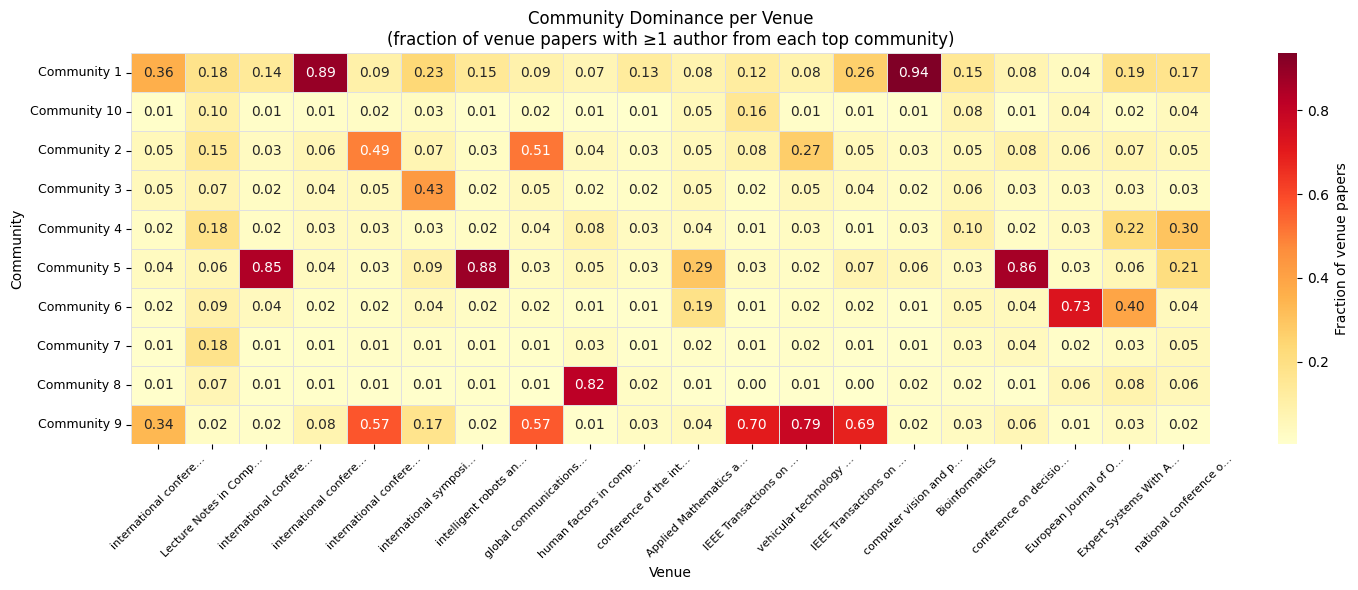

/tmp/ipykernel_40149/4017302194.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bar_cmap = plt.cm.get_cmap("tab10", TOP_COMMUNITIES)


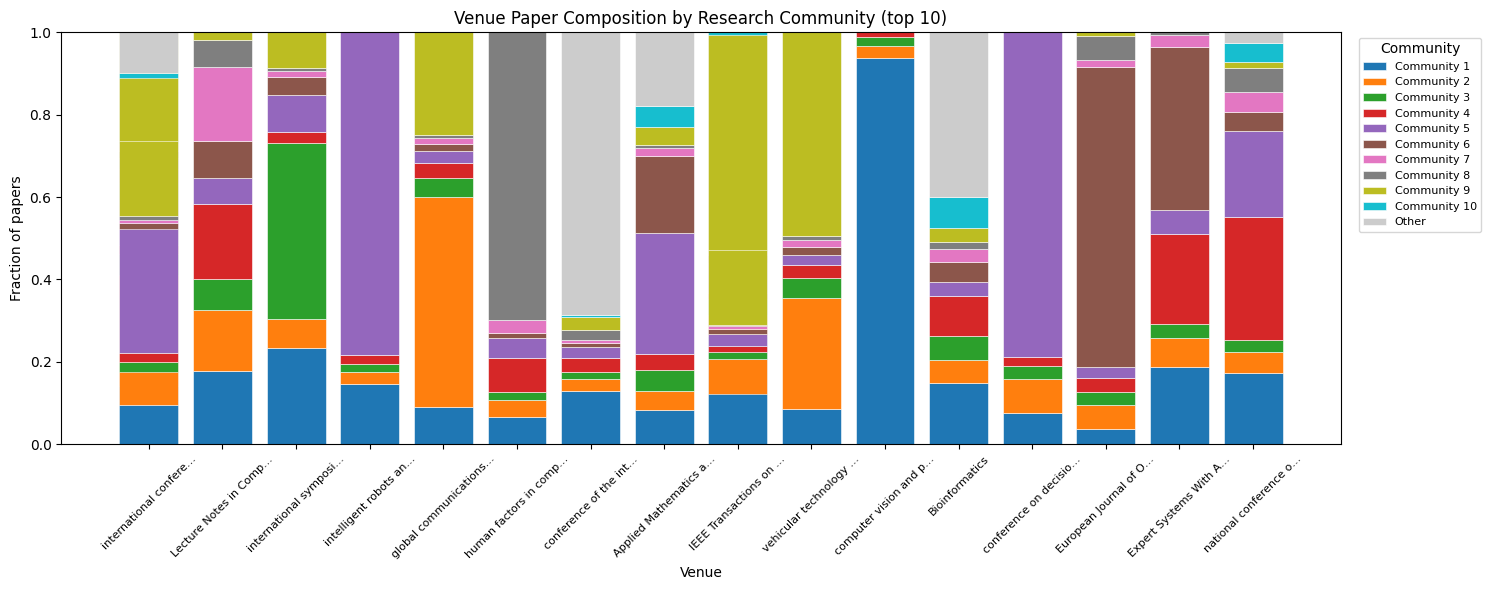

Dominant community per venue (by fraction):

  international confere…    →  Community 1  (36.1% of 22,783 papers)
  Lecture Notes in Comp…    →  Community 4  (18.4% of 22,268 papers)
  international confere…    →  Community 5  (84.5% of 18,472 papers)
  international confere…    →  Community 1  (89.1% of 15,370 papers)
  international confere…    →  Community 9  (57.5% of 14,866 papers)
  international symposi…    →  Community 3  (42.7% of 13,585 papers)
  intelligent robots an…    →  Community 5  (88.5% of 12,869 papers)
  global communications…    →  Community 9  (56.7% of 12,772 papers)
  human factors in comp…    →  Community 8  (81.7% of 11,038 papers)
  conference of the int…    →  Community 1  (13.0% of 10,583 papers)
  Applied Mathematics a…    →  Community 5  (29.4% of 10,568 papers)
  IEEE Transactions on …    →  Community 9  (70.3% of 9,762 papers)
  vehicular technology …    →  Community 9  (78.5% of 9,708 papers)
  IEEE Transactions on …    →  Community 9  (68.7% of 9,639 

In [ ]:
"""Task 3: Analyze collaboration patterns — do certain author groups dominate certain venues?"""
# Map each author (in the top communities) to a readable label
author_to_comm_label = {}
for rank, cid in enumerate(top_comm_ids, 1):
    for a in communities[cid]:
        author_to_comm_label[a] = f"Community {rank}"

# Work with papers that have a valid venue and at least one author
valid = (
    sample_set['venue'].notna()
    & (sample_set['venue'].astype(str).str.strip() != '')
    & sample_set['authors'].notna()
)
working = sample_set.loc[valid, ['id', 'venue', 'authors']].copy()

# Choose the top N venues by paper count
venue_totals = working.groupby('venue').size()
top_venue_list = venue_totals.nlargest(TOP_VENUES_T3).index.tolist()
working = working[working['venue'].isin(top_venue_list)]

# Explode so each row is (paper_id, venue, author), map to community label
exploded = working.explode('authors').rename(columns={'authors': 'author'})
exploded['community'] = exploded['author'].map(author_to_comm_label)
exploded = exploded.dropna(subset=['community'])

# Deduplicate: count each (paper, community) pair only once
# (avoids inflating when several co-authors belong to the same community)
unique_pairs = exploded.drop_duplicates(subset=['id', 'community'])

# Build community × venue count matrix, then normalise by venue total
count_matrix = (
    unique_pairs.groupby(['community', 'venue'])
    .size()
    .unstack('venue', fill_value=0)
    .reindex(columns=top_venue_list, fill_value=0)
)
norm_matrix = count_matrix.divide(venue_totals[top_venue_list], axis=1)

# Shorten long venue names so they fit on axes
def _shorten(name, n=22):
    return name if len(name) <= n else name[: n - 1] + "…"

short_venues = [_shorten(v) for v in top_venue_list]
norm_matrix.columns = short_venues
count_matrix.columns = short_venues

#  Plot 1: Heatmap — fraction of each venue's papers authored by each community 
fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(
    norm_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="#e0e0e0",
    cbar_kws={"label": "Fraction of venue papers"},
    ax=ax,
)
ax.set_title(
    "Community Dominance per Venue\n"
    "(fraction of venue papers with ≥1 author from each top community)",
    fontsize=12,
)
ax.set_xlabel("Venue", fontsize=10)
ax.set_ylabel("Community", fontsize=10)
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)
plt.tight_layout()
plt.show()


#  Plot 2: Stacked bar — per-venue paper share broken down by community 
community_labels = [f"Community {r}" for r in range(1, TOP_COMMUNITIES + 1)]

bar_cmap = plt.get_cmap("tab10", TOP_COMMUNITIES)
colors = {f"Community {r}": bar_cmap(r - 1) for r in range(1, TOP_COMMUNITIES + 1)}
colors["Other"] = "#cccccc" # type: ignore

# "Other" absorbs the remainder so bars sum to 1
other_row = (1.0 - norm_matrix.sum(axis=0)).clip(lower=0)
plot_df = norm_matrix.reindex(community_labels, fill_value=0)
plot_df.loc["Other"] = other_row

fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(short_venues))
for label in community_labels + ["Other"]:
    vals = plot_df.loc[label].values.astype(float)
    ax.bar(short_venues, vals, bottom=bottom,
           color=colors[label], label=label, edgecolor="white", linewidth=0.4)
    bottom += vals

ax.set_title(
    f"Venue Paper Composition by Research Community (top {TOP_COMMUNITIES})",
    fontsize=12,
)
ax.set_xlabel("Venue", fontsize=10)
ax.set_ylabel("Fraction of papers", fontsize=10)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, title="Community")
plt.tight_layout()
plt.show()


#  Summary: dominant community per venue 
print("Dominant community per venue (by fraction):\n")
for col_idx, (short, full) in enumerate(zip(short_venues, top_venue_list)):
    col_data = norm_matrix.iloc[:, col_idx]
    dominant = col_data.idxmax()
    frac = float(col_data.max())
    total = int(venue_totals[full])
    print(f"  {short:<24}  →  {dominant}  ({frac:.1%} of {total:,} papers)")


## Task 3 output

```shell
Dominant community per venue (by fraction):

  international confere…    →  Community 1  (36.1% of 22,783 papers)
  Lecture Notes in Comp…    →  Community 4  (18.4% of 22,268 papers)
  international confere…    →  Community 5  (84.5% of 18,472 papers)
  international confere…    →  Community 1  (89.1% of 15,370 papers)
  international confere…    →  Community 9  (57.5% of 14,866 papers)
  international symposi…    →  Community 3  (42.7% of 13,585 papers)
  intelligent robots an…    →  Community 5  (88.5% of 12,869 papers)
  global communications…    →  Community 9  (56.7% of 12,772 papers)
  human factors in comp…    →  Community 8  (81.7% of 11,038 papers)
  conference of the int…    →  Community 1  (13.0% of 10,583 papers)
  Applied Mathematics a…    →  Community 5  (29.4% of 10,568 papers)
  IEEE Transactions on …    →  Community 9  (70.3% of 9,762 papers)
  vehicular technology …    →  Community 9  (78.5% of 9,708 papers)
  IEEE Transactions on …    →  Community 9  (68.7% of 9,639 papers)
  computer vision and p…    →  Community 1  (93.7% of 9,399 papers)
  Bioinformatics            →  Community 1  (14.9% of 9,346 papers)
  conference on decisio…    →  Community 5  (86.3% of 9,319 papers)
  European Journal of O…    →  Community 6  (72.9% of 9,017 papers)
  Expert Systems With A…    →  Community 6  (39.6% of 8,765 papers)
  national conference o…    →  Community 4  (30.0% of 8,548 papers)
```